# Project 2 — Image Recognition 🖼️

Uses a **pretrained** deep learning model (MobileNetV2) to identify the main object in a photo — no training required.

⚠️ **This notebook needs internet access** the first time you run it (to download the model weights ~14MB, and a sample image if you don't upload your own). It will work in Google Colab or any Jupyter environment with internet.

## Cell 1: Imports + Load the Pretrained Model

We use **transfer learning** — instead of training our own model (which would need millions of images), we load MobileNetV2, already trained on ImageNet (1000 object categories, 1M+ images).

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.utils import load_img, img_to_array

print("TensorFlow version:", tf.__version__)

# First run downloads ~14 MB of pretrained weights — one-time only
image_model = MobileNetV2(weights="imagenet")
print("Pretrained MobileNetV2 loaded successfully.")


TensorFlow version: 2.21.0
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Pretrained MobileNetV2 loaded successfully.


## Cell 2: Provide an Image

- **In Google Colab:** an upload dialog opens — pick any photo from your device.
- **Elsewhere / if you skip the upload:** it automatically downloads a sample image so the notebook still works.

The image is resized to 224×224 pixels — the exact size MobileNetV2 expects.

ℹ️ Using sample image: sample_image.jpg (re-run this cell to upload your own)


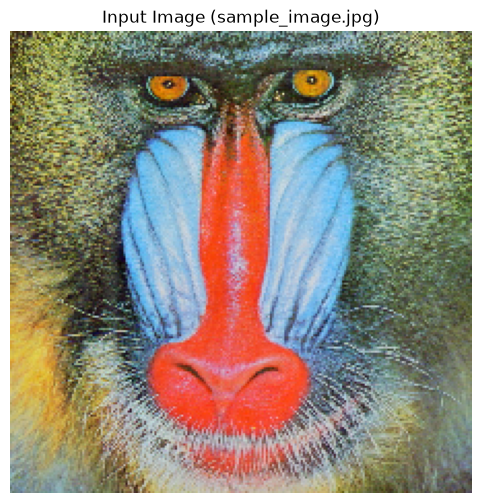

In [3]:
import os
import urllib.request

FALLBACK_IMAGE_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg"
FALLBACK_IMAGE_PATH = "sample_image.jpg"
image_path = None

# Option A: upload your own image (works in Google Colab)
try:
    from google.colab import files
    print("📤 Upload an image (jpg/png). Cancel/skip to use a sample image instead.")
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
except ImportError:
    pass  # not running in Colab

# Option B: guaranteed fallback
if not image_path:
    if not os.path.exists(FALLBACK_IMAGE_PATH):
        urllib.request.urlretrieve(FALLBACK_IMAGE_URL, FALLBACK_IMAGE_PATH)
    image_path = FALLBACK_IMAGE_PATH
    print(f"ℹ️ Using sample image: {image_path} (re-run this cell to upload your own)")

image = load_img(image_path, target_size=(224, 224))

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Input Image ({image_path})")
plt.show()


## Cell 3: Prepare the Image for the Model

The model needs a specific numeric shape: `(batch_size, height, width, channels)`. Steps:
1. `img_to_array()` — image → array of numbers
2. `expand_dims()` — wraps it as a batch of 1
3. `preprocess_input()` — scales pixel values the same way the model was trained on (skipping this gives bad predictions)

In [4]:
image_array = img_to_array(image)
image_batch = np.expand_dims(image_array, axis=0)
processed_image = preprocess_input(image_batch)

print("Original shape:", image_array.shape)
print("Batch shape:", image_batch.shape)


Original shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)


## Cell 4: Get the Model's Prediction

The model outputs 1000 probability scores — one per ImageNet category. `decode_predictions()` converts these into the top 5 human-readable labels.

In [5]:
import time

start_time = time.time()
predictions = image_model.predict(processed_image, verbose=0)
elapsed_ms = (time.time() - start_time) * 1000

decoded_predictions = decode_predictions(predictions, top=5)[0]

print(f"Prediction took {elapsed_ms:.1f} ms")
print("\nTop Predictions:")
for _, label, probability in decoded_predictions:
    print(f"{label}: {probability * 100:.2f}%")


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
Prediction took 27462.3 ms

Top Predictions:
baboon: 49.88%
vulture: 1.01%
jackfruit: 0.65%
wild_boar: 0.57%
ostrich: 0.56%


## Note: What Actually Happened

The model didn't "see" the image like a human. It transformed a grid of numbers through many layers until it produced a probability for each of 1000 known categories. A high score means strong pattern match — **not** guaranteed correctness. A blurry photo, an unfamiliar object, or multiple objects in frame can all fool it.